# FAOSTAT Visualization and Analysis

Olive fruit production, harvested area and yield for all FAOSTAT reporting
countries, 1961–2024.

This notebook produces the FAOSTAT figures used in the presentation and the
blog post, and runs the statistical test behind the production-alternation
claim. Every figure is written to `outputs/figures/faostat/`.

## 1. Imports and Setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# One shared palette so every figure in the deck matches.
COUNTRY_COLORS = {
    "Spain": "#DDA01A",
    "Türkiye": "#C0272D",
    "Italy": "#2E7D52",
}

# Darker variants, used for text labels so they stay readable on white.
LABEL_COLORS = {
    "Spain": "#A8760A",
    "Türkiye": "#A11F24",
    "Italy": "#1F5E3C",
}

INK = "#1A1A1A"
MUTED = "#5F6672"
GRID = "#E4E7EB"
BACKGROUND_LINE = "#D7DBE0"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

## 2. Load the Data

The notebook is designed to run from the Big-Olive repository. It locates the
repository root and loads the processed FAOSTAT data from
`data/processed/faostat_all_countries.csv`.


In [3]:
def find_project_root():
    """Locate the Big-Olive repository root from the current directory."""
    current = Path.cwd().resolve()

    # The notebook may be launched from the repo root or from notebooks/.
    for directory in [current, *current.parents]:
        if (
            (directory / "data" / "processed").exists()
            and (directory / "src").exists()
            and (directory / "notebooks").exists()
        ):
            return directory

    raise FileNotFoundError(
        "Could not locate the Big-Olive repository root. "
        "Run this notebook from the repository or from its notebooks folder."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "faostat_all_countries.csv"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "faostat"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find processed FAOSTAT data at: {DATA_PATH}"
    )

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, dtype={"m49_code": "string"})
df = df.sort_values(["country", "year"]).reset_index(drop=True)

print("Project root:", PROJECT_ROOT)
print("Data:", DATA_PATH)
print("Figures:", FIGURE_DIR)

df.head()


Project root: /Users/alberto/Documents/Big-Olive
Data: /Users/alberto/Documents/Big-Olive/data/processed/faostat_all_countries.csv
Figures: /Users/alberto/Documents/Big-Olive/outputs/figures/faostat


,faostat_country_code,m49_code,country,year,production_tonnes,production_flag,area_harvested_ha,area_harvested_flag,yield_kg_ha,yield_flag
0,2,004,Afghanistan,1961,1000.0,E,600.0,E,1666.7,E
1,2,004,Afghanistan,1962,1100.0,E,600.0,E,1833.3,E
2,2,004,Afghanistan,1963,1000.0,E,600.0,E,1666.7,E
3,2,004,Afghanistan,1964,1100.0,E,600.0,E,1833.3,E
4,2,004,Afghanistan,1965,1000.0,E,600.0,E,1666.7,E


## 3. Dataset Checks

In [4]:
print("Shape:", df.shape)
print("Years:", df["year"].min(), "to", df["year"].max())
print("Countries:", df["country"].nunique())
print()

# The three countries the story follows
for country in COUNTRY_COLORS:
    country_df = df[df["country"] == country]
    latest = country_df.dropna(subset=["production_tonnes"]).iloc[-1]
    print(
        f"{country:<9} latest year {int(latest['year'])}: "
        f"{latest['production_tonnes'] / 1_000_000:.2f}M tonnes"
    )

print()
print("Missing production values:", df["production_tonnes"].isna().sum())

Shape: (2481, 10)
Years: 1961 to 2024
Countries: 62

Spain     latest year 2024: 8.31M tonnes
Türkiye   latest year 2024: 3.75M tonnes
Italy     latest year 2024: 2.30M tonnes

Missing production values: 168


## 4. Figure Saving Helper

Every figure is written at 220 dpi into `outputs/figures/faostat/`, so the
deck and the blog post always pull the same files.

In [5]:
def save_figure(fig, filename, dpi=220):
    """Save a figure as PNG and report where it went."""
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=dpi, facecolor="white")
    print("Saved:", output_path)
    return output_path


## 5. Production Paths Across Countries

All FAOSTAT producers are drawn in light grey so the three countries in the
story can be read against the full field rather than in isolation.

Saved: /Users/alberto/Documents/Big-Olive/outputs/figures/faostat/olive_production_all_countries.png


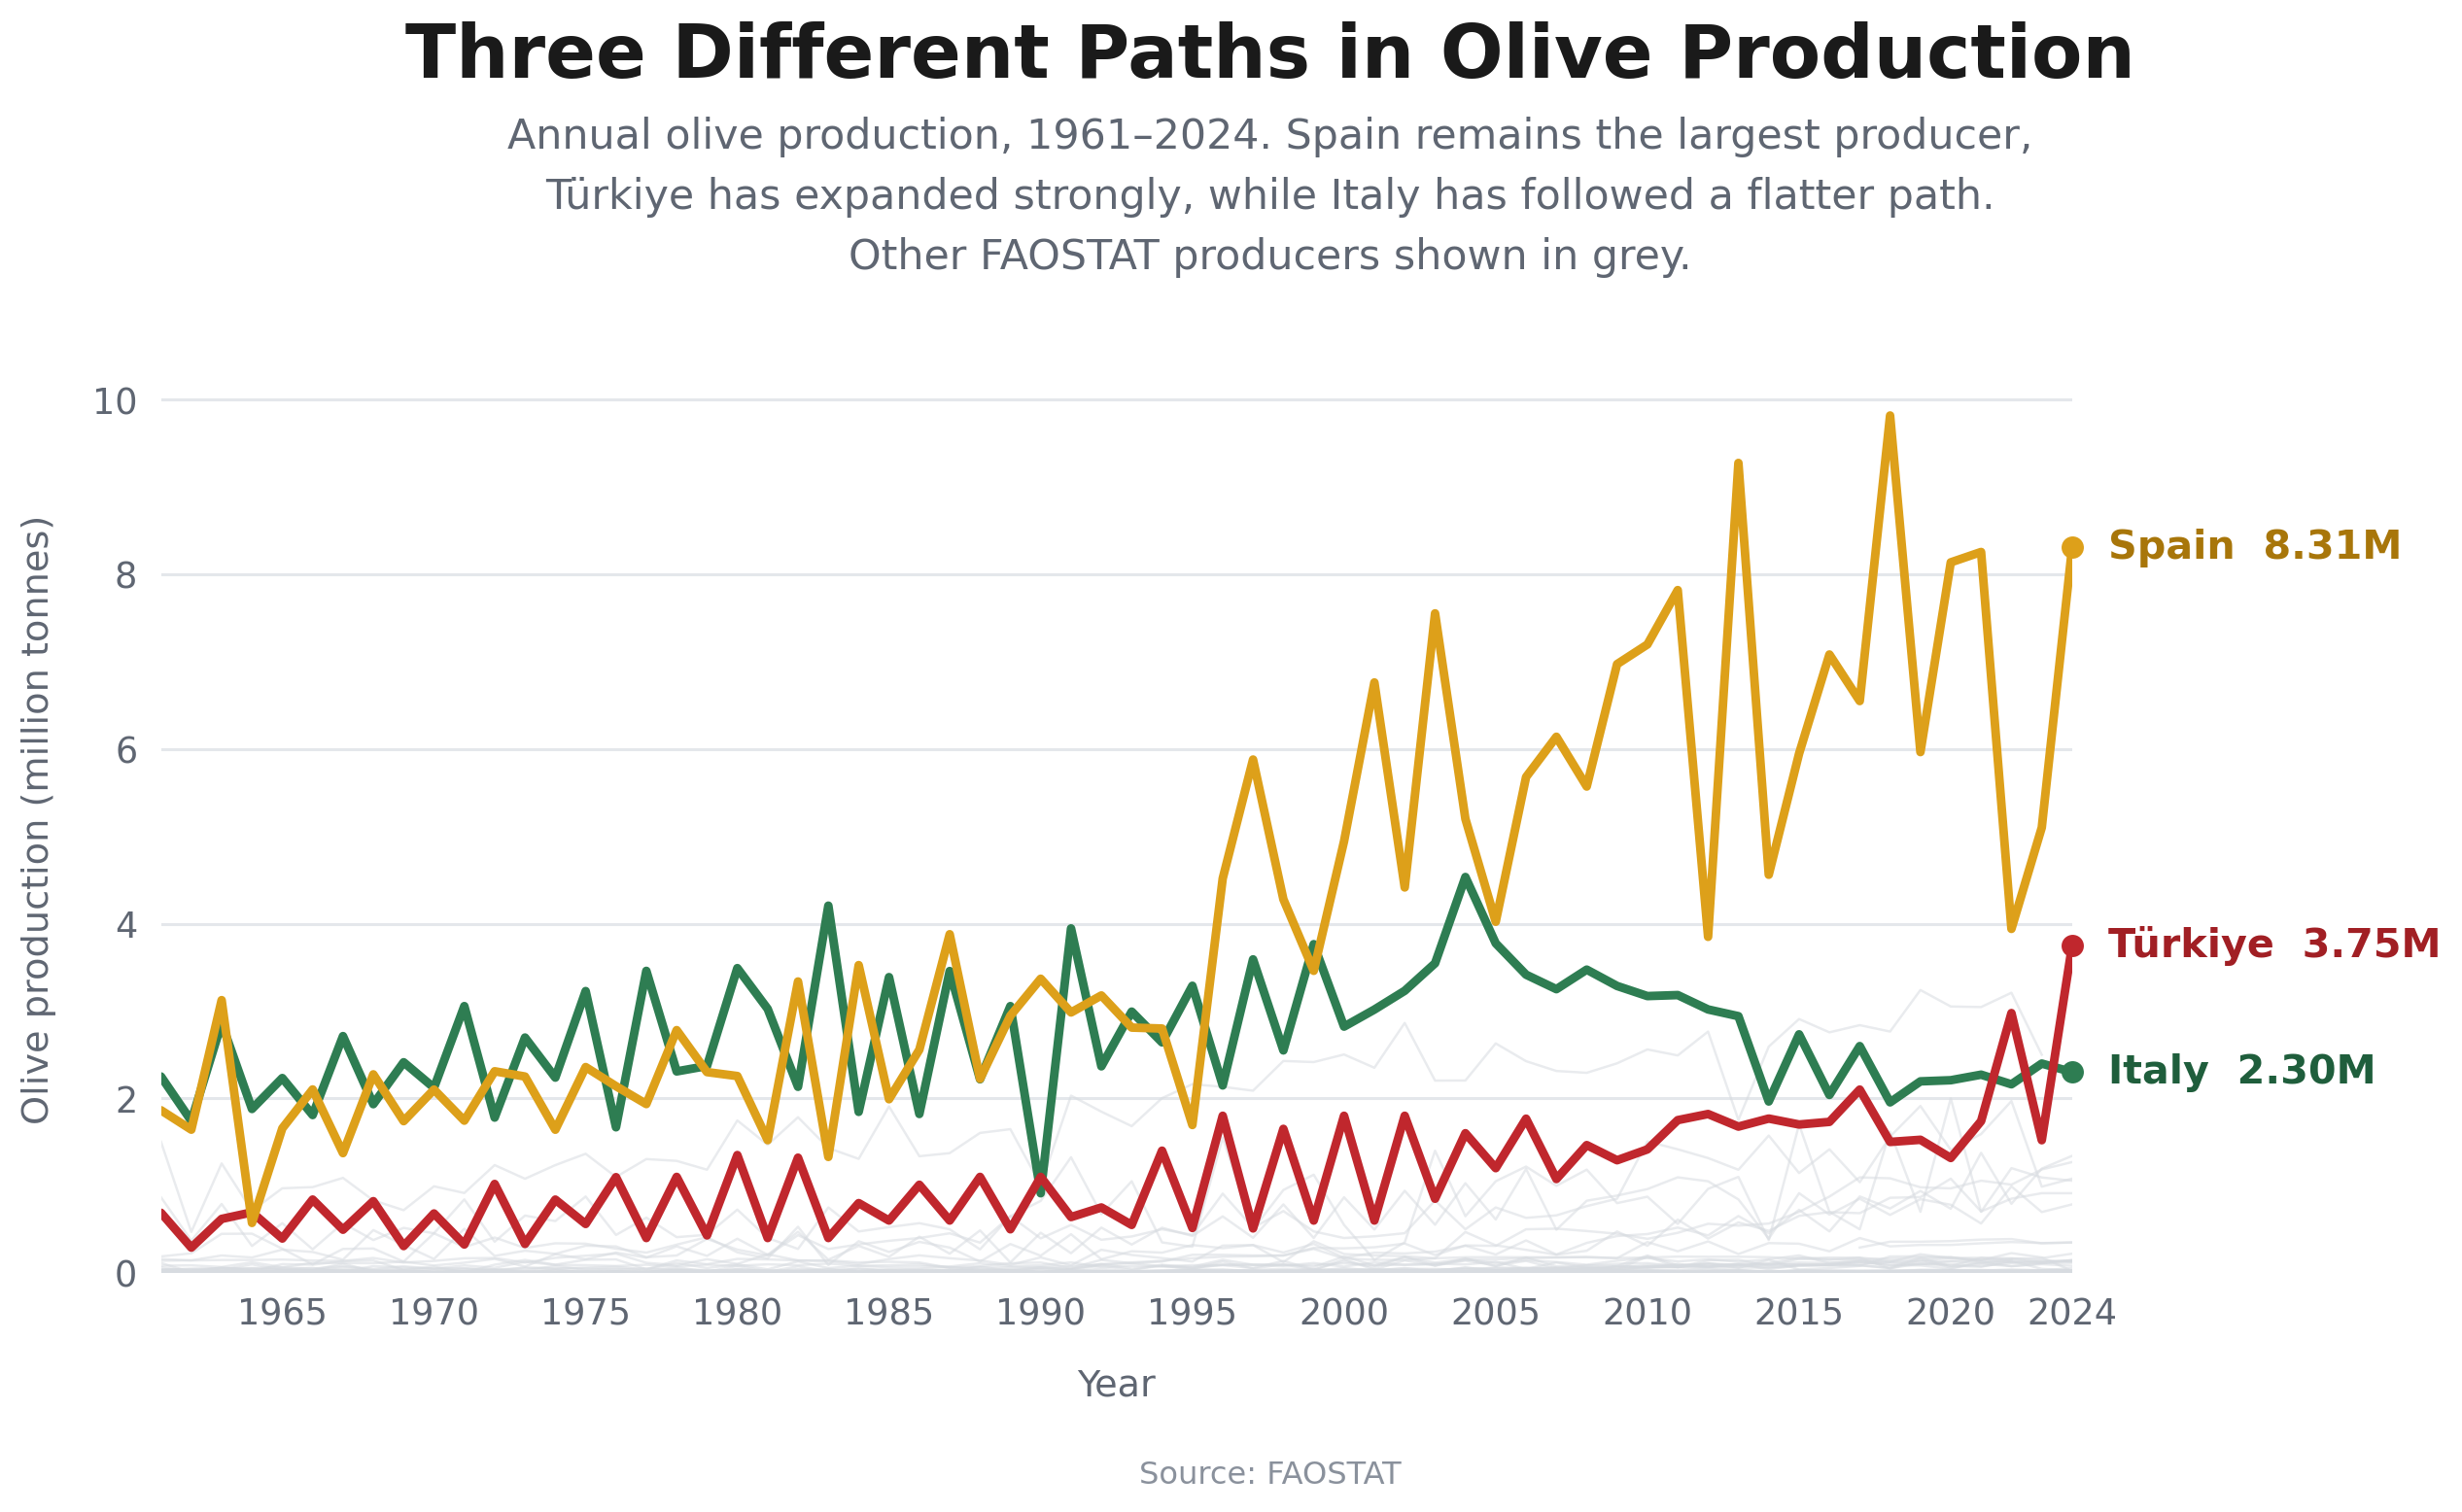

In [6]:
HIGHLIGHT = ["Italy", "Türkiye", "Spain"]  # drawn last, so Spain sits on top

fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=220)
fig.subplots_adjust(left=0.085, right=0.80, top=0.755, bottom=0.165)

# Background: every other reporting country, unchanged annual values
for country, country_df in df.groupby("country"):
    if country in HIGHLIGHT:
        continue

    country_df = country_df.sort_values("year")

    ax.plot(
        country_df["year"],
        country_df["production_tonnes"] / 1_000_000,
        color=BACKGROUND_LINE,
        linewidth=0.8,
        alpha=0.55,
        zorder=1,
    )

# Foreground: the three countries the story follows
for i, country in enumerate(HIGHLIGHT):
    country_df = df[df["country"] == country].sort_values("year")

    ax.plot(
        country_df["year"],
        country_df["production_tonnes"] / 1_000_000,
        color=COUNTRY_COLORS[country],
        linewidth=2.9,
        zorder=3 + i,
        solid_capstyle="round",
    )

    # Label each line at its most recent value instead of using a legend
    last_row = country_df.dropna(subset=["production_tonnes"]).iloc[-1]
    last_value = last_row["production_tonnes"] / 1_000_000

    ax.plot(
        [last_row["year"]],
        [last_value],
        "o",
        color=COUNTRY_COLORS[country],
        markersize=6.5,
        zorder=6,
        clip_on=False,
    )

    ax.annotate(
        f"{country}  {last_value:.2f}M",
        xy=(last_row["year"], last_value),
        xytext=(12, 0),
        textcoords="offset points",
        color=LABEL_COLORS[country],
        fontsize=13.5,
        fontweight="bold",
        va="center",
        annotation_clip=False,
    )

# Axes
ax.set_xlim(df["year"].min(), df["year"].max())
ax.set_ylim(0, 10.4)
ax.set_yticks(range(0, 11, 2))
ax.set_yticklabels([str(t) for t in range(0, 11, 2)], fontsize=12, color=MUTED)

year_ticks = list(range(1965, 2021, 5)) + [2024]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(t) for t in year_ticks], fontsize=12, color=MUTED)

ax.tick_params(axis="both", length=0, pad=8)
ax.set_xlabel("Year", fontsize=12.5, color=MUTED, labelpad=12)
ax.set_ylabel(
    "Olive production (million tonnes)",
    fontsize=12.5,
    color=MUTED,
    labelpad=12,
)

ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)

for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)

# Titles, centred over the whole figure
fig.text(
    0.5, 0.955,
    "Three Different Paths in Olive Production",
    ha="center", va="center", fontsize=25, fontweight="bold", color=INK,
)

subtitle_lines = [
    "Annual olive production, 1961–2024. Spain remains the largest producer,",
    "Türkiye has expanded strongly, while Italy has followed a flatter path.",
    "Other FAOSTAT producers shown in grey.",
]

for i, line in enumerate(subtitle_lines):
    fig.text(
        0.5, 0.903 - i * 0.039, line,
        ha="center", va="center", fontsize=14, color=MUTED,
    )

fig.text(0.5, 0.028, "Source: FAOSTAT", ha="center", fontsize=10.5, color="#8A919C")

save_figure(fig, "olive_production_all_countries.png")
plt.show()

**Key observation:** Spain is the largest producer in absolute terms and has
led every year since 2000. Türkiye expanded strongly and overtook Italy in
2024. Italy's line stays within roughly the same band across the whole period,
which is what the next two figures examine.

## 6. Different Paths of Agricultural Change

Production growth can come from two places: planting more hectares, or getting
more out of each hectare. Comparing ten-year averages rather than single years
avoids the biennial bearing cycle of olive trees.

Yield is derived as *average production / average harvested area* rather than
averaged directly, so it stays consistent with the other two columns.

In [7]:
COMPARISON_COUNTRIES = ["Spain", "Türkiye", "Italy"]
COMPARISON_COLUMNS = ["area_harvested_ha", "production_tonnes"]

EARLY_PERIOD = (1981, 1990)
RECENT_PERIOD = (2015, 2024)

comparison_df = df[df["country"].isin(COMPARISON_COUNTRIES)].copy()

# Fail loudly if a country is missing rather than plotting a silent gap
countries_found = set(comparison_df["country"].unique())

if countries_found != set(COMPARISON_COUNTRIES):
    raise ValueError(
        f"Expected {COMPARISON_COUNTRIES}, but found {sorted(countries_found)}"
    )


def period_averages(frame, start_year, end_year):
    """Ten-year averages per country, with yield derived from the averages."""
    period = (
        frame[frame["year"].between(start_year, end_year)]
        .groupby("country")[COMPARISON_COLUMNS]
        .mean()
    )

    period["yield_kg_ha"] = (
        period["production_tonnes"] * 1000 / period["area_harvested_ha"]
    )

    return period


early_period = period_averages(comparison_df, *EARLY_PERIOD)
recent_period = period_averages(comparison_df, *RECENT_PERIOD)

long_term_change = (recent_period / early_period - 1) * 100

long_term_change = (
    long_term_change
    .rename(columns={
        "area_harvested_ha": "Harvested area",
        "yield_kg_ha": "Yield",
        "production_tonnes": "Production",
    })
    [["Harvested area", "Yield", "Production"]]
    .reindex(COMPARISON_COUNTRIES)
)

long_term_change.round(1)

,Harvested area,Yield,Production
country,,,
Spain,25.8,106.0,159.1
Türkiye,70.4,48.9,153.6
Italy,-5.4,-7.3,-12.3


Saved: /Users/alberto/Documents/Big-Olive/outputs/figures/faostat/agricultural_change_flag_colors.png


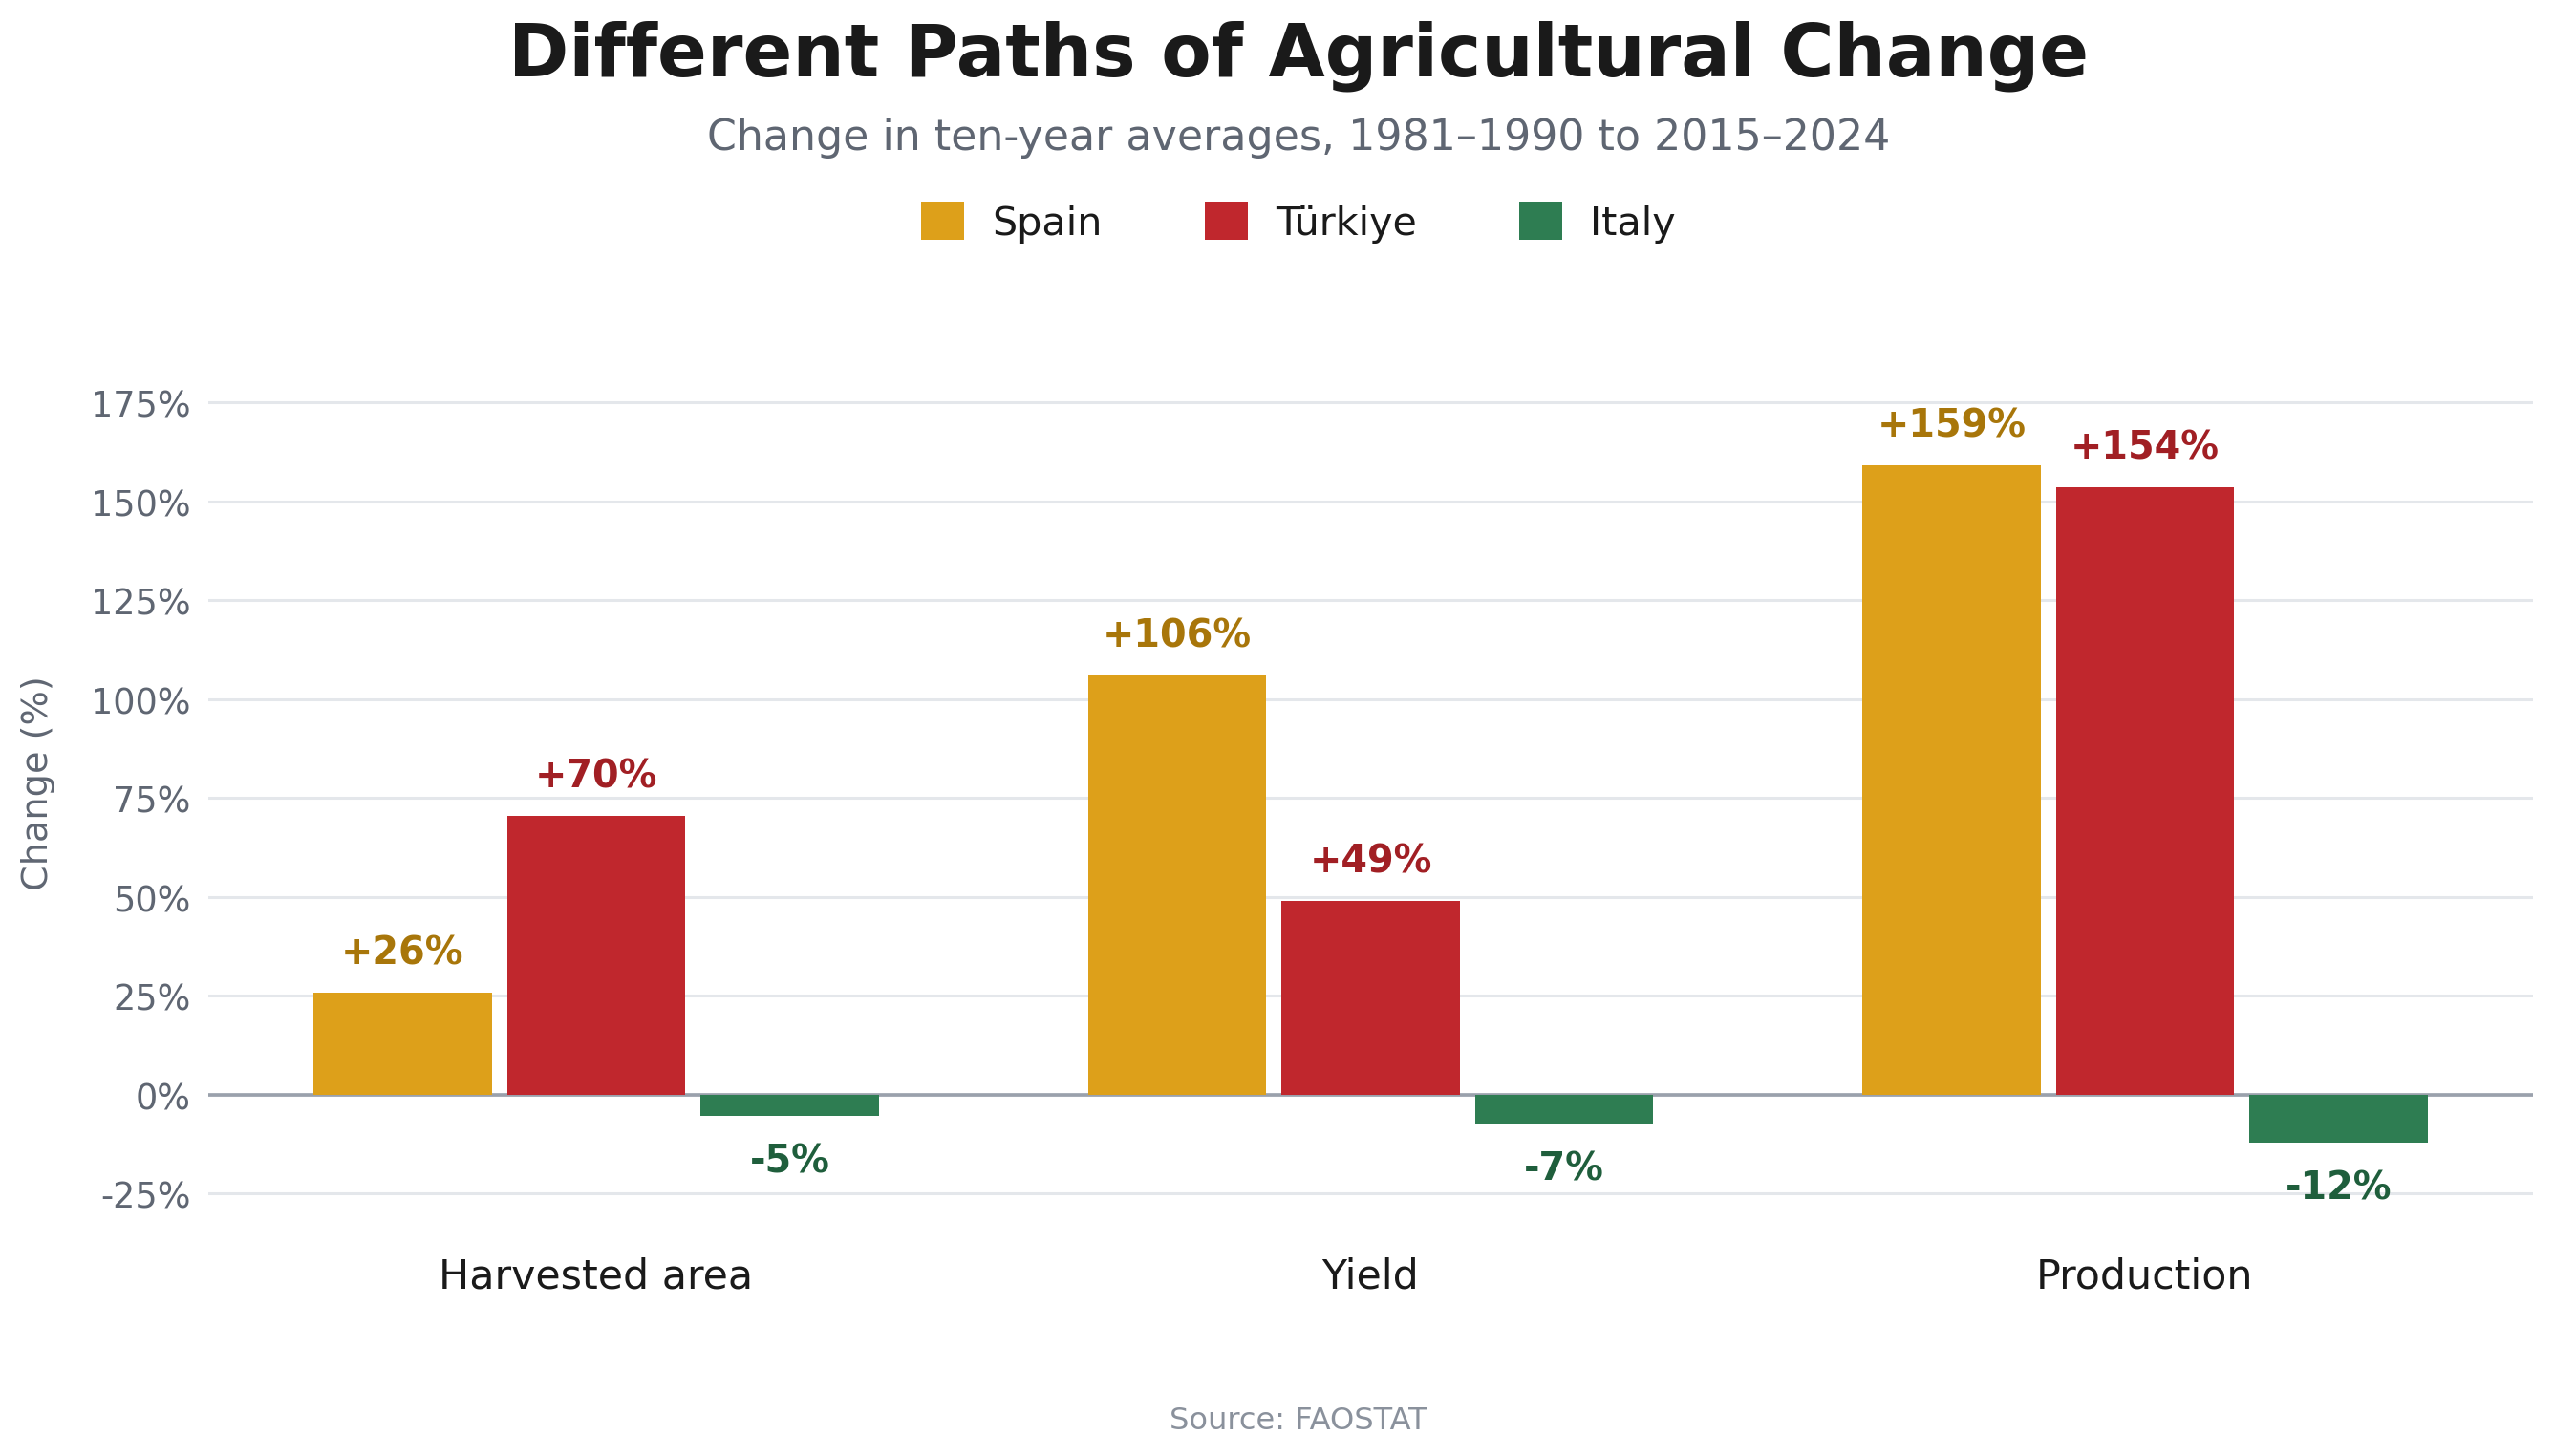

In [8]:
metrics = ["Harvested area", "Yield", "Production"]
x = np.arange(len(metrics))
width = 0.25
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=220)
fig.subplots_adjust(left=0.085, right=0.97, top=0.745, bottom=0.165)

for country, offset in zip(COMPARISON_COUNTRIES, offsets):
    values = long_term_change.loc[country, metrics].values

    bars = ax.bar(
        x + offset,
        values,
        width * 0.92,
        label=country,
        color=COUNTRY_COLORS[country],
        edgecolor="none",
        zorder=3,
    )

    # Value labels: above positive bars, below negative ones
    for bar, value in zip(bars, values):
        is_positive = value >= 0

        ax.annotate(
            f"{value:+.0f}%",
            xy=(bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, 7 if is_positive else -9),
            textcoords="offset points",
            ha="center",
            va="bottom" if is_positive else "top",
            fontsize=13,
            fontweight="bold",
            color=LABEL_COLORS[country],
            zorder=4,
        )

# Axes
ax.set_ylim(-32, 190)
ax.set_yticks(np.arange(-25, 200, 25))
ax.set_yticklabels(
    [f"{t}%" for t in np.arange(-25, 200, 25)], fontsize=12, color=MUTED
)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=14, color=INK)
ax.tick_params(axis="x", length=0, pad=12)
ax.tick_params(axis="y", length=0, pad=6)

ax.set_ylabel("Change (%)", fontsize=12.5, color=MUTED, labelpad=12)

ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
ax.axhline(0, color="#9AA1AC", linewidth=1.2, zorder=2)

for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)

# Titles and legend, centred
fig.text(
    0.5, 0.935,
    "Different Paths of Agricultural Change",
    ha="center", va="center", fontsize=25, fontweight="bold", color=INK,
)

fig.text(
    0.5, 0.881,
    f"Change in ten-year averages, {EARLY_PERIOD[0]}–{EARLY_PERIOD[1]}"
    f" to {RECENT_PERIOD[0]}–{RECENT_PERIOD[1]}",
    ha="center", va="center", fontsize=14.5, color=MUTED,
)

handles, labels = ax.get_legend_handles_labels()

legend = fig.legend(
    handles, labels,
    loc="center", bbox_to_anchor=(0.5, 0.825),
    ncol=3, frameon=False, fontsize=13.5,
    handlelength=1.1, handleheight=1.1, handletextpad=0.7, columnspacing=2.6,
)

for text in legend.get_texts():
    text.set_color(INK)

fig.text(0.5, 0.028, "Source: FAOSTAT", ha="center", fontsize=10.5, color="#8A919C")

save_figure(fig, "agricultural_change_flag_colors.png")
plt.show()

**Key observation:** Spain and Türkiye grew production by a similar amount
(+159% and +154%), but through different routes. Spain's gain came mostly from
yield (+106% against +26% area); Türkiye's came mostly from planting
(+70% area against +49% yield). Italy is negative on all three.

*Caveat worth stating out loud:* the 1981–1990 baseline is Italy's strongest
decade, which makes its decline look steeper than it would against the 1960s.
The next figure uses the start of the series instead.

## 7. Italy Against the Rest of the World

Indexing removes the scale difference between a 6M tonne producer and a 2M
tonne one, so the two lines can be compared directly.

Two choices matter here. The base is the 1961–1965 *average* rather than a
single year, because olive harvests alternate. And the world total covers only
the countries that report in every year of the period, so the rise cannot be
an artefact of new countries joining the dataset over time.

In [9]:
BASE_PERIOD = slice(1961, 1965)

wide = df.pivot(index="year", columns="country", values="production_tonnes")

# Balanced panel: countries reporting every year, so coverage cannot drive the trend
balanced_countries = wide.loc[1961:2023].dropna(axis=1).columns

print(f"Balanced panel: {len(balanced_countries)} of {wide.shape[1]} countries")
print(
    "2024 total, balanced vs all: "
    f"{wide[balanced_countries].loc[2024].sum() / 1e6:.2f}M vs "
    f"{wide.loc[2024].sum() / 1e6:.2f}M tonnes"
)

world = wide[balanced_countries].sum(axis=1)
italy = wide["Italy"]

index_world = world / world.loc[BASE_PERIOD].mean() * 100
index_italy = italy / italy.loc[BASE_PERIOD].mean() * 100

# Five-year centred means, plotted over the raw annual values
smooth_world = index_world.rolling(5, center=True, min_periods=3).mean()
smooth_italy = index_italy.rolling(5, center=True, min_periods=3).mean()

pd.DataFrame({
    "Italy (index)": index_italy.loc[[1961, 1990, 2024]].round(0),
    "All producers (index)": index_world.loc[[1961, 1990, 2024]].round(0),
})

Balanced panel: 30 of 62 countries
2024 total, balanced vs all: 22.47M vs 22.90M tonnes


,Italy (index),All producers (index)
year,,
1961,103.0,114.0
1990,42.0,125.0
2024,105.0,312.0


Saved: /Users/alberto/Documents/Big-Olive/outputs/figures/faostat/italy_flat_vs_world.png


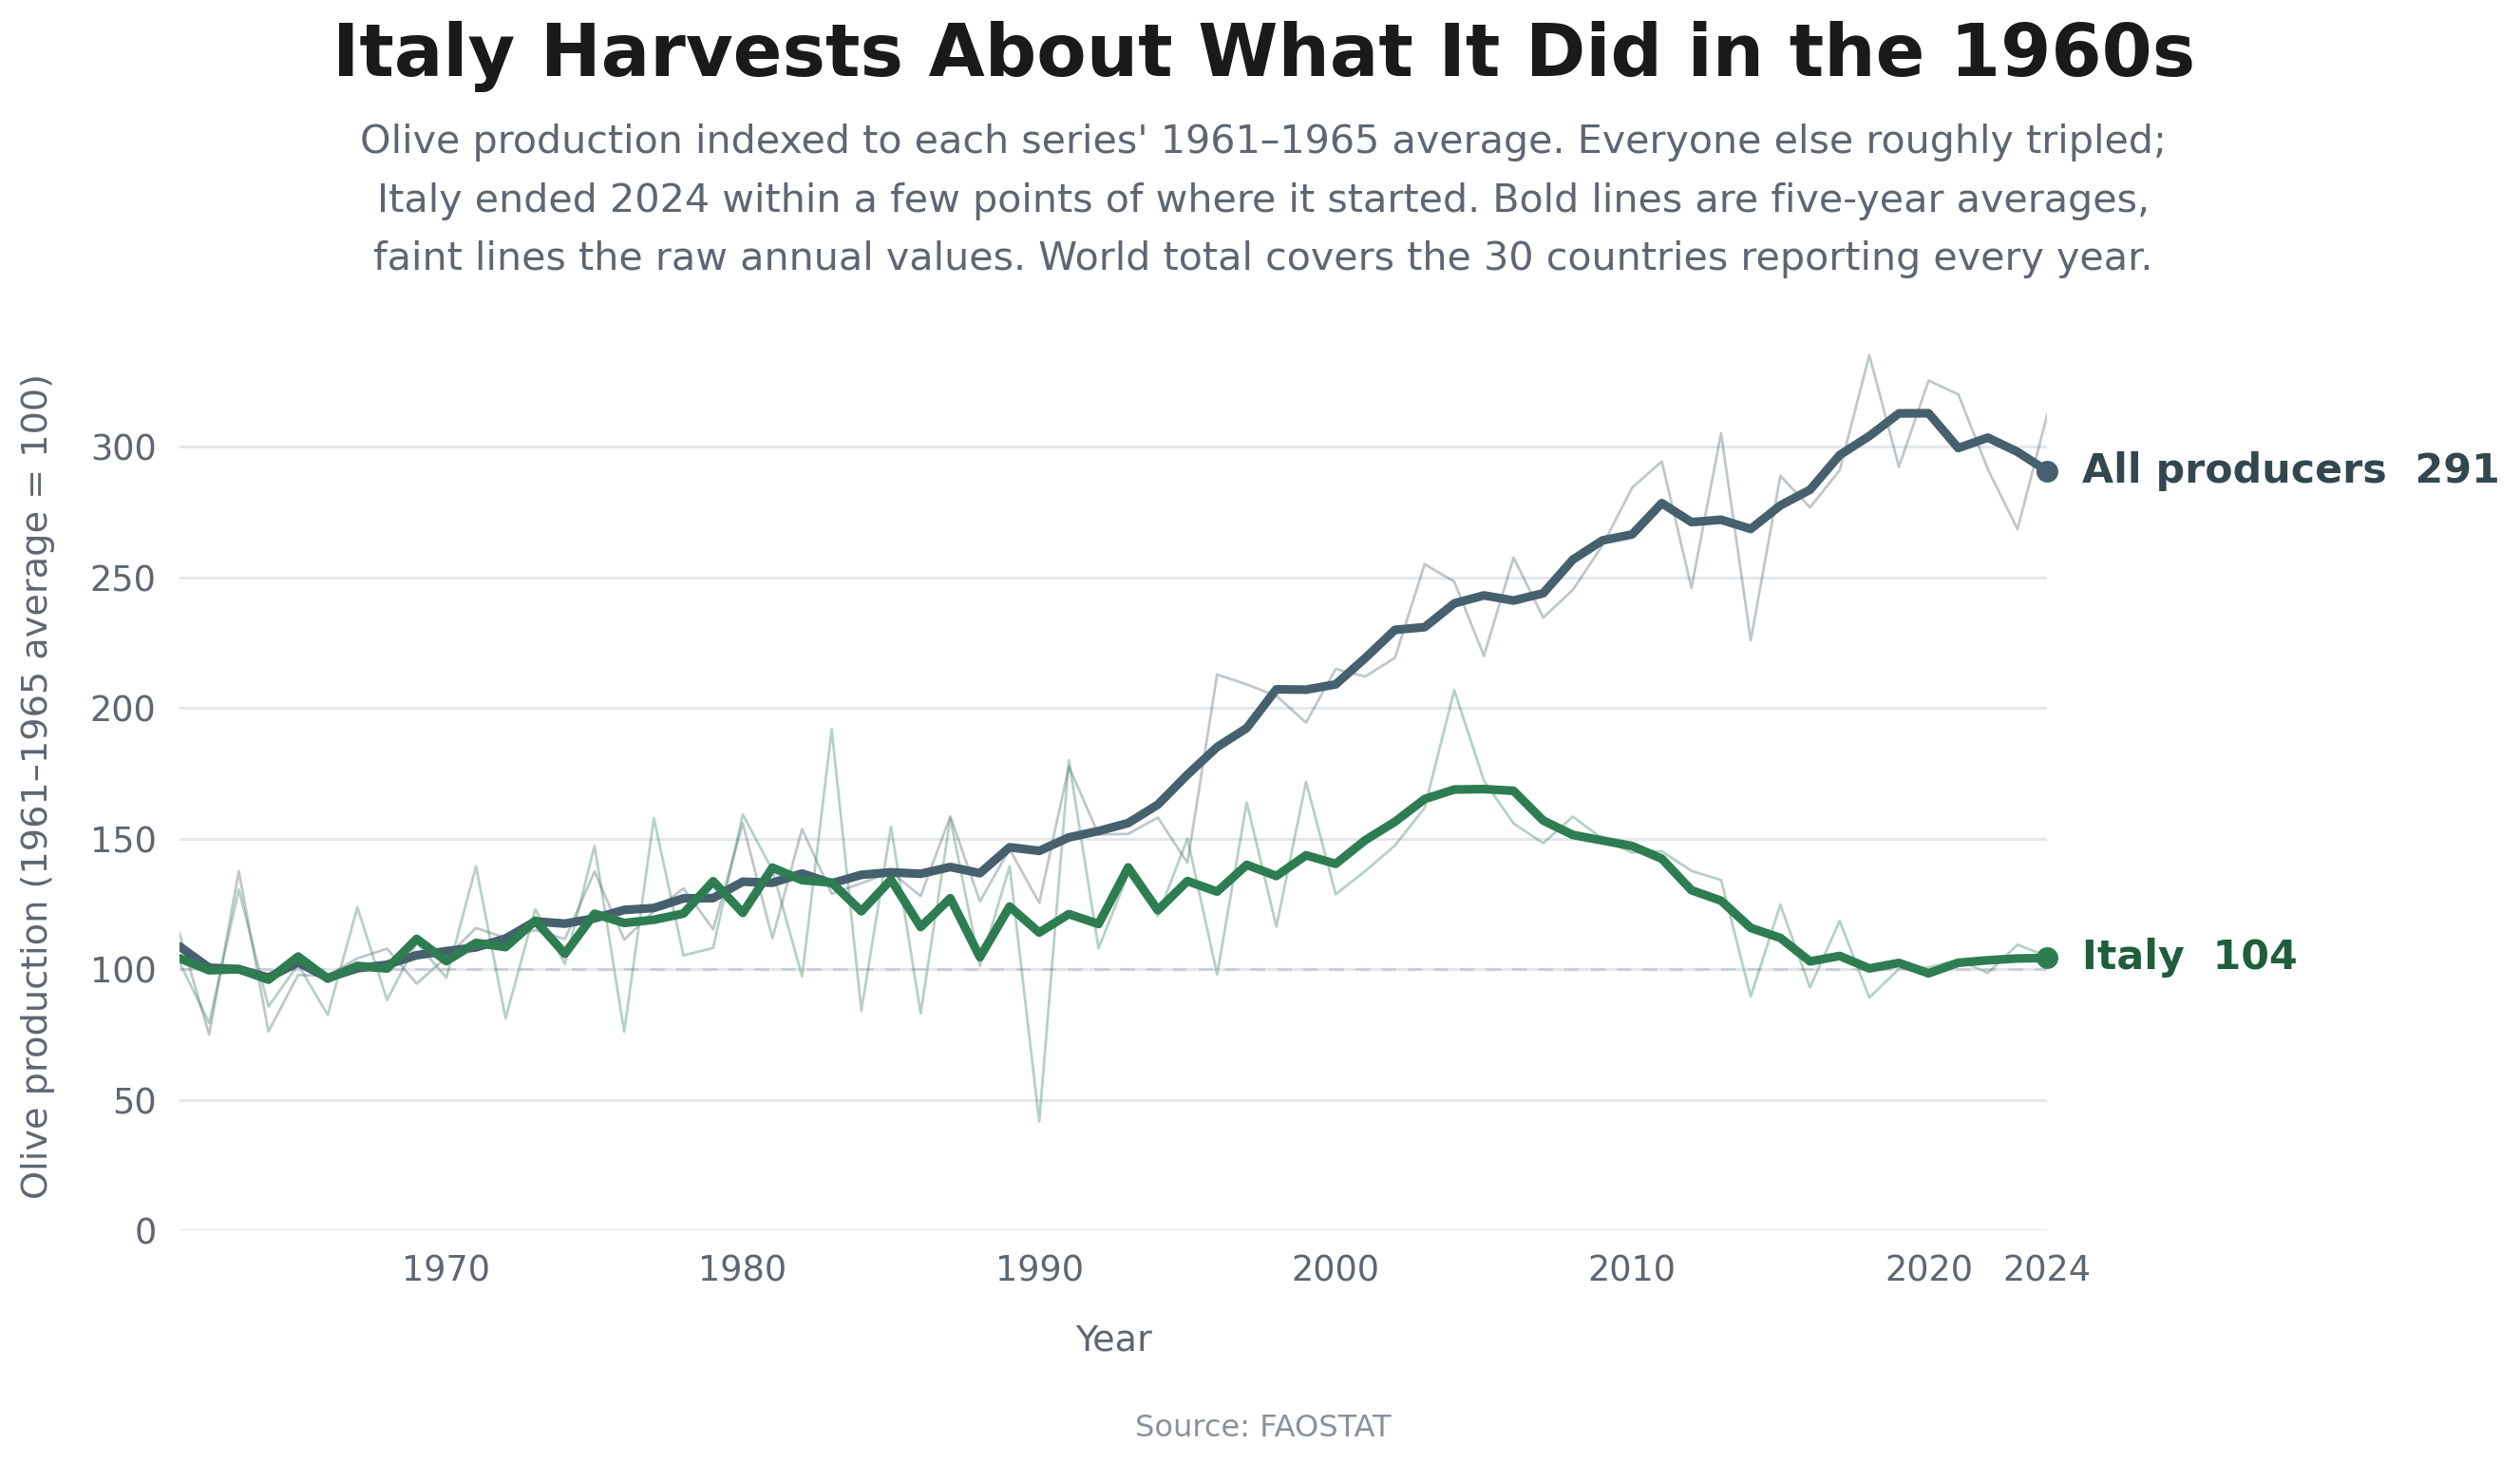

In [10]:
WORLD_COLOR, WORLD_LABEL = "#46606E", "#33474F"

fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=220)
fig.subplots_adjust(left=0.085, right=0.80, top=0.755, bottom=0.165)

# Raw annual values, faint
ax.plot(index_world.index, index_world, color=WORLD_COLOR,
        linewidth=0.9, alpha=0.35, zorder=2)
ax.plot(index_italy.index, index_italy, color=COUNTRY_COLORS["Italy"],
        linewidth=0.9, alpha=0.35, zorder=2)

# Five-year averages, bold
ax.plot(smooth_world.index, smooth_world, color=WORLD_COLOR,
        linewidth=3.0, zorder=4, solid_capstyle="round")
ax.plot(smooth_italy.index, smooth_italy, color=COUNTRY_COLORS["Italy"],
        linewidth=3.0, zorder=5, solid_capstyle="round")

# Reference line at the base level
ax.axhline(100, color="#C9CED6", linewidth=1, linestyle=(0, (5, 4)), zorder=1)

for series, color, label_color, name in [
    (smooth_world, WORLD_COLOR, WORLD_LABEL, "All producers"),
    (smooth_italy, COUNTRY_COLORS["Italy"], LABEL_COLORS["Italy"], "Italy"),
]:
    valid = series.dropna()
    x_last, y_last = valid.index[-1], valid.iloc[-1]

    ax.plot([x_last], [y_last], "o", color=color, markersize=6.5,
            zorder=6, clip_on=False)

    ax.annotate(
        f"{name}  {y_last:.0f}",
        xy=(x_last, y_last),
        xytext=(12, 0),
        textcoords="offset points",
        color=label_color,
        fontsize=14,
        fontweight="bold",
        va="center",
        annotation_clip=False,
    )

ax.set_xlim(1961, 2024)
ax.set_ylim(0, 340)
ax.set_yticks(range(0, 350, 50))
ax.set_yticklabels([str(t) for t in range(0, 350, 50)], fontsize=12, color=MUTED)

year_ticks = list(range(1970, 2021, 10)) + [2024]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(t) for t in year_ticks], fontsize=12, color=MUTED)

ax.tick_params(axis="both", length=0, pad=8)
ax.set_xlabel("Year", fontsize=12.5, color=MUTED, labelpad=12)
ax.set_ylabel(
    "Olive production (1961–1965 average = 100)",
    fontsize=12.5, color=MUTED, labelpad=12,
)

ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)

for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)

fig.text(
    0.5, 0.945,
    "Italy Harvests About What It Did in the 1960s",
    ha="center", va="center", fontsize=25, fontweight="bold", color=INK,
)

subtitle_lines = [
    "Olive production indexed to each series' 1961–1965 average. Everyone else roughly tripled;",
    "Italy ended 2024 within a few points of where it started. Bold lines are five-year averages,",
    "faint lines the raw annual values. World total covers the 30 countries reporting every year.",
]

for i, line in enumerate(subtitle_lines):
    fig.text(0.5, 0.888 - i * 0.039, line,
             ha="center", va="center", fontsize=13.5, color=MUTED)

fig.text(0.5, 0.028, "Source: FAOSTAT", ha="center", fontsize=10.5, color="#8A919C")

save_figure(fig, "italy_flat_vs_world.png")
plt.show()

**Key observation:** indexed to their own 1961–1965 average, the rest of the
world's producers roughly tripled while Italy ended 2024 at about 104. Italy
did peak near 170 between 1995 and 2005 before falling back, so "flat" describes
the endpoints rather than every year in between.

## 8. Year-to-Year Production Rhythm

Olive trees bear biennially: a heavy year is usually followed by a light one.
This figure shows only the *direction* of each year's change, not its size, so
the rhythm is visible without the magnitudes getting in the way.

Saved: /Users/alberto/Documents/Big-Olive/outputs/figures/faostat/faostat_direction_rhythm.png


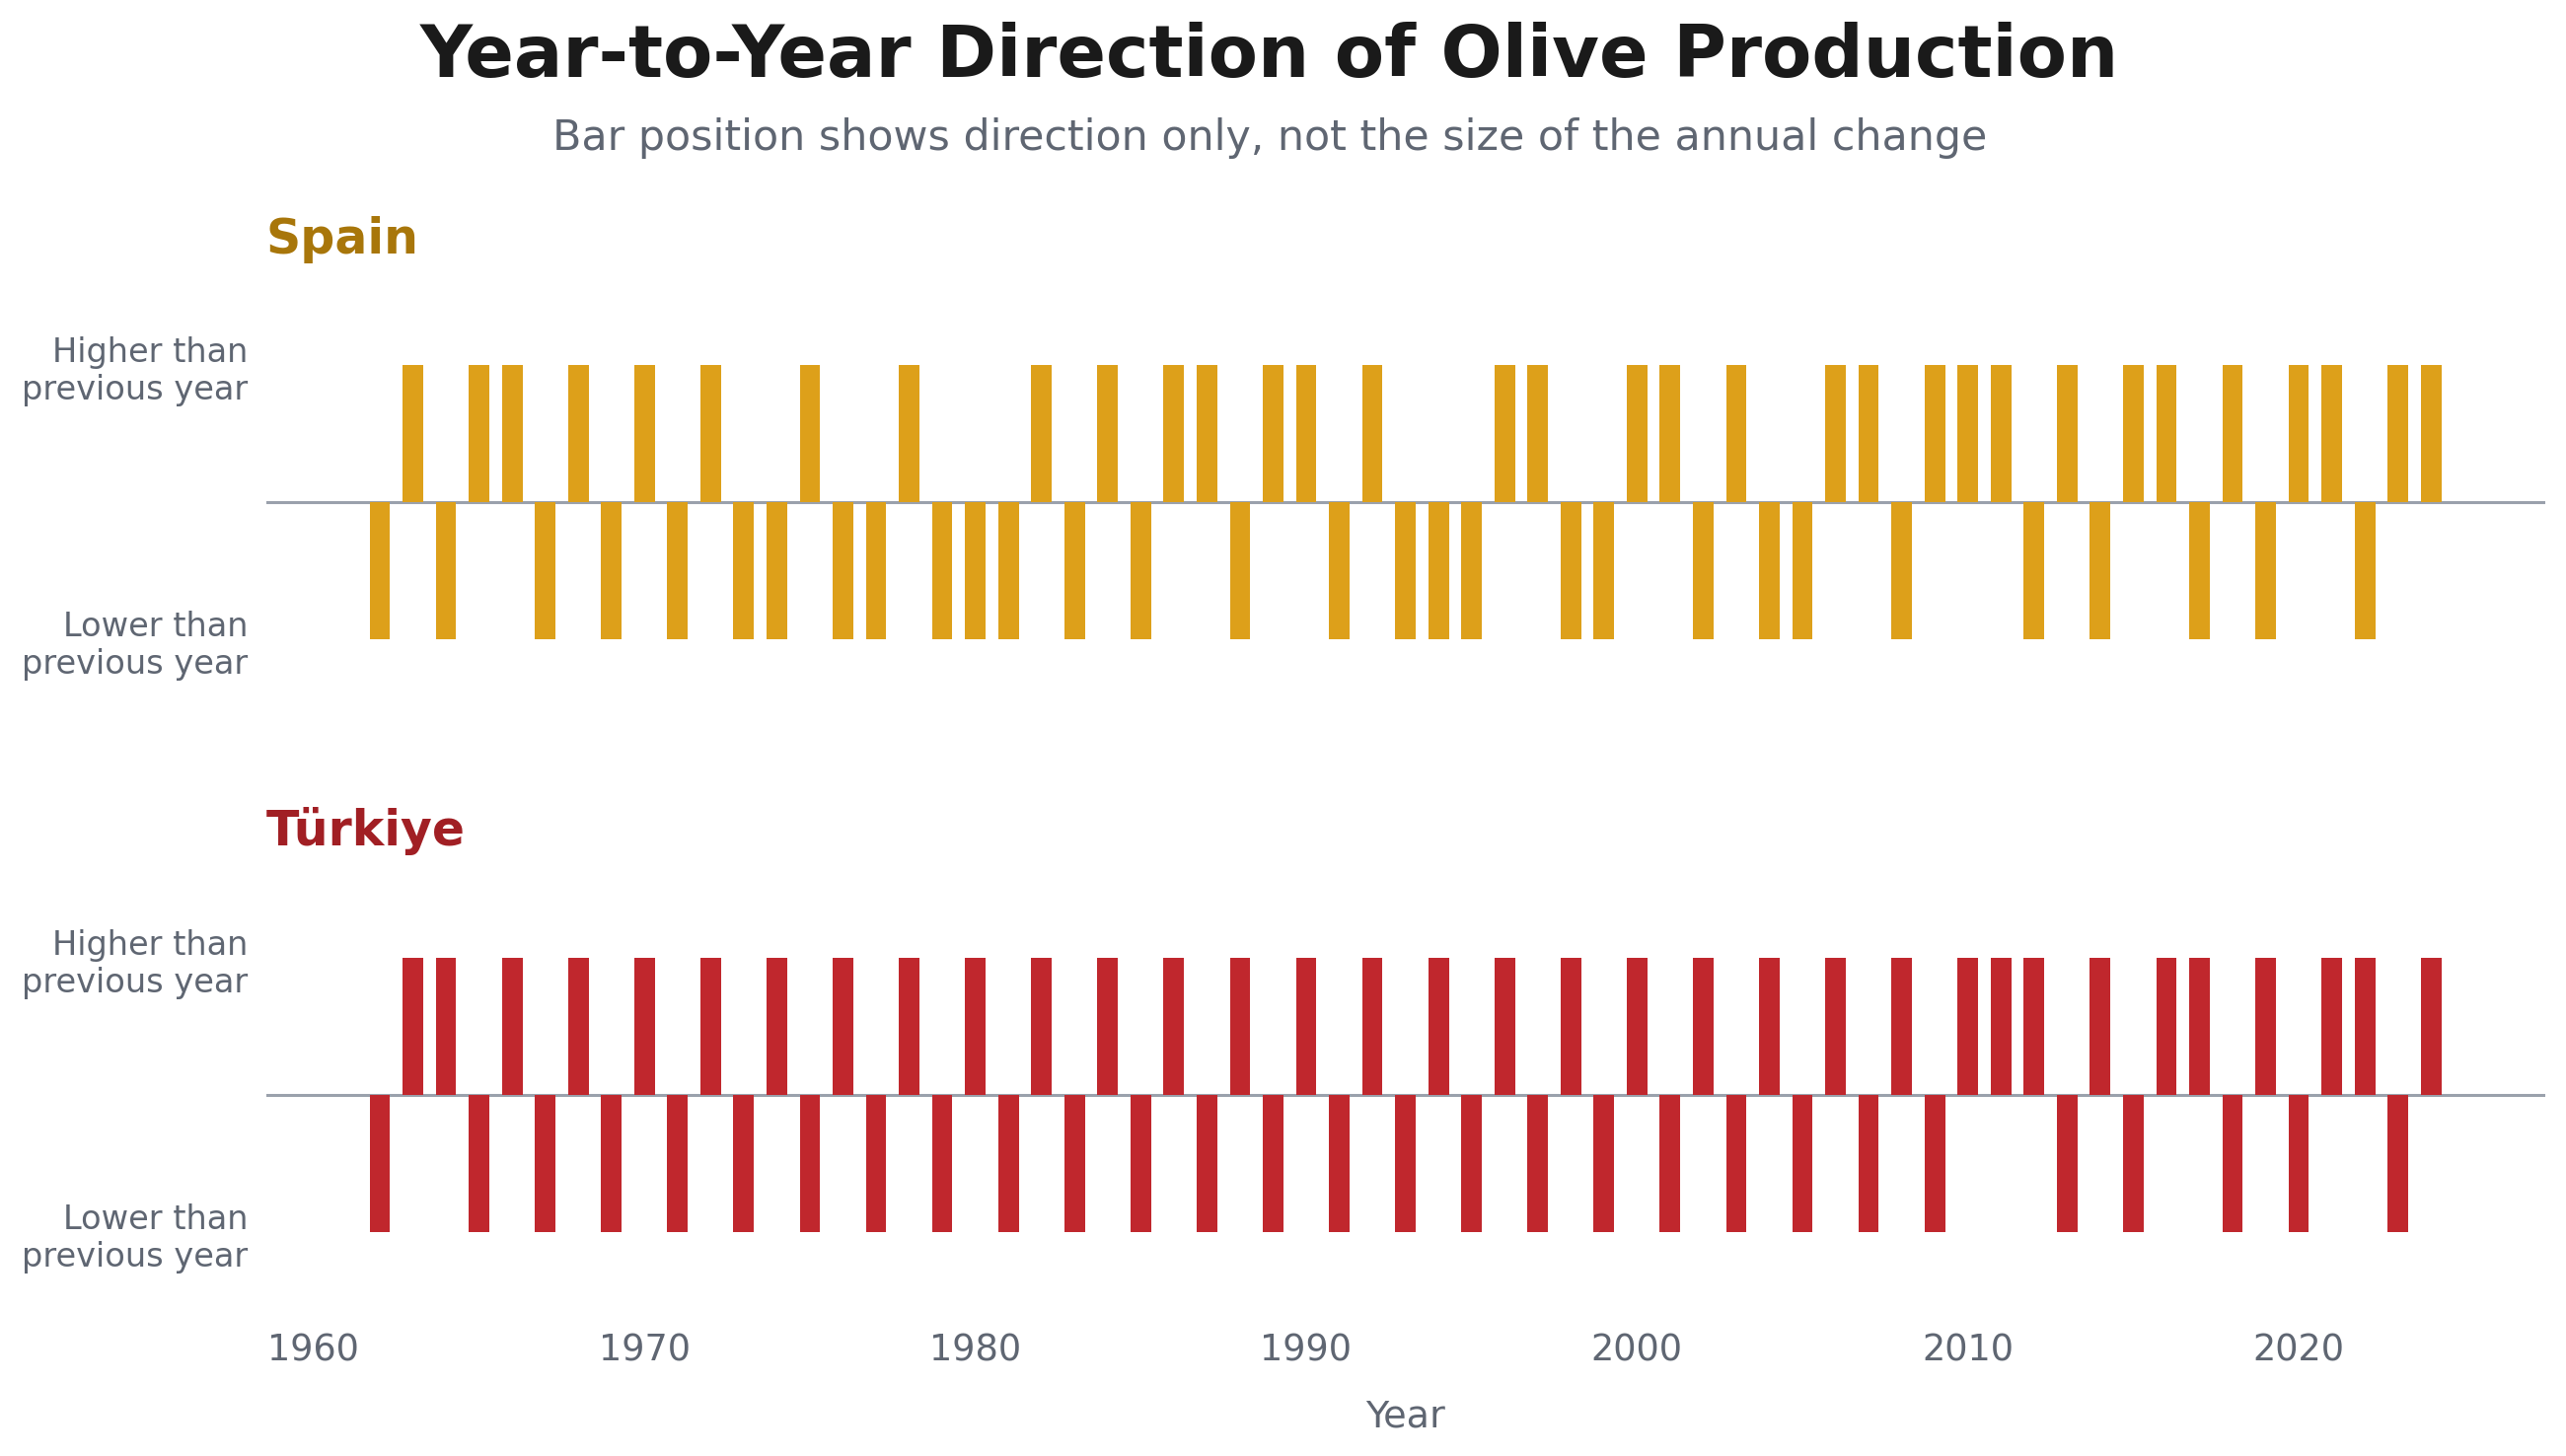

In [11]:
RHYTHM_COUNTRIES = ["Spain", "Türkiye"]

# Use the engineered feature if the features file was loaded, otherwise derive it
if "production_direction" in df.columns:
    direction_source = df.copy()
else:
    direction_source = df.copy()
    direction_source["production_change"] = (
        direction_source.groupby("country")["production_tonnes"].diff()
    )
    direction_source["production_direction"] = np.select(
        [
            direction_source["production_change"] > 0,
            direction_source["production_change"] < 0,
        ],
        ["increase", "decrease"],
        default=None,
    )

fig, axes = plt.subplots(
    len(RHYTHM_COUNTRIES), 1, figsize=(12.5, 7.2), dpi=220, sharex=True
)
fig.subplots_adjust(left=0.13, right=0.97, top=0.80, bottom=0.14, hspace=0.35)

for ax, country in zip(axes, RHYTHM_COUNTRIES):
    country_df = (
        direction_source[
            (direction_source["country"] == country)
            & (direction_source["production_direction"].isin(["increase", "decrease"]))
        ]
        .sort_values("year")
    )

    heights = np.where(
        country_df["production_direction"].eq("increase"), 1, -1
    )

    ax.bar(
        country_df["year"], heights,
        width=0.62, color=COUNTRY_COLORS[country], zorder=3,
    )

    ax.axhline(0, color="#9AA1AC", linewidth=1, zorder=2)
    ax.set_ylim(-1.6, 1.6)
    ax.set_yticks([1, -1])
    ax.set_yticklabels(
        ["Higher than\nprevious year", "Lower than\nprevious year"],
        fontsize=11, color=MUTED,
    )

    ax.set_title(
        country, loc="left", fontsize=16, fontweight="bold",
        color=LABEL_COLORS[country], pad=10,
    )

    ax.tick_params(axis="both", length=0, pad=6)

    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)

axes[-1].set_xlabel("Year", fontsize=12.5, color=MUTED, labelpad=10)
axes[-1].tick_params(axis="x", labelsize=12, colors=MUTED)

fig.text(
    0.5, 0.945,
    "Year-to-Year Direction of Olive Production",
    ha="center", va="center", fontsize=24, fontweight="bold", color=INK,
)

fig.text(
    0.5, 0.893,
    "Bar position shows direction only, not the size of the annual change",
    ha="center", va="center", fontsize=14, color=MUTED,
)

save_figure(fig, "faostat_direction_rhythm.png")
plt.show()

**Supporting observation:** Türkiye switches direction far more often than
Spain, which shows longer runs in the same direction. Section 9 tests whether
that difference is larger than chance would produce.

## 9. Quantifying Production Alternation

The visual pattern needs a test. We compare the observed number of direction
switches against 50,000 random reorderings of the same set of increases and
decreases. Shuffling keeps the count of up and down years fixed and only
destroys their order, so the null is "same years, no rhythm".

The p-value uses the (count + 1) / (n + 1) form, which avoids reporting p = 0
when no permutation beats the observed value.

In [12]:
ANALYSIS_PERIODS = {
    "1961–1990": (1961, 1990),
    "1991–2024": (1991, 2024),
}

N_PERMUTATIONS = 50_000

rng = np.random.default_rng(510)  # fixed seed so the p-values reproduce

results = []

for country in RHYTHM_COUNTRIES:
    for period_name, (start_year, end_year) in ANALYSIS_PERIODS.items():
        period_df = (
            direction_source[
                (direction_source["country"] == country)
                & (direction_source["year"].between(start_year, end_year))
                & (direction_source["production_direction"].isin(["increase", "decrease"]))
            ]
            .sort_values("year")
        )

        directions = period_df["production_direction"].to_numpy()

        observed_switches = (directions[1:] != directions[:-1]).sum()
        comparisons = len(directions) - 1
        observed_rate = observed_switches / comparisons * 100

        null_rates = np.empty(N_PERMUTATIONS)

        for i in range(N_PERMUTATIONS):
            shuffled = rng.permutation(directions)
            null_rates[i] = (shuffled[1:] != shuffled[:-1]).mean() * 100

        p_value = (np.sum(null_rates >= observed_rate) + 1) / (N_PERMUTATIONS + 1)

        results.append({
            "country": country,
            "period": period_name,
            "observed_alternation_pct": observed_rate,
            "random_mean_pct": null_rates.mean(),
            "p_value": p_value,
        })

alternation_results = pd.DataFrame(results)
alternation_results.round(3)

,country,period,observed_alternation_pct,random_mean_pct,p_value
0,Spain,1961–1990,75.000,51.748,0.011
1,Spain,1991–2024,63.636,50.790,0.092
2,Türkiye,1961–1990,96.429,51.753,0.000
3,Türkiye,1991–2024,87.879,50.773,0.000


Saved: /Users/alberto/Documents/Big-Olive/outputs/figures/faostat/faostat_alternation_rates.png


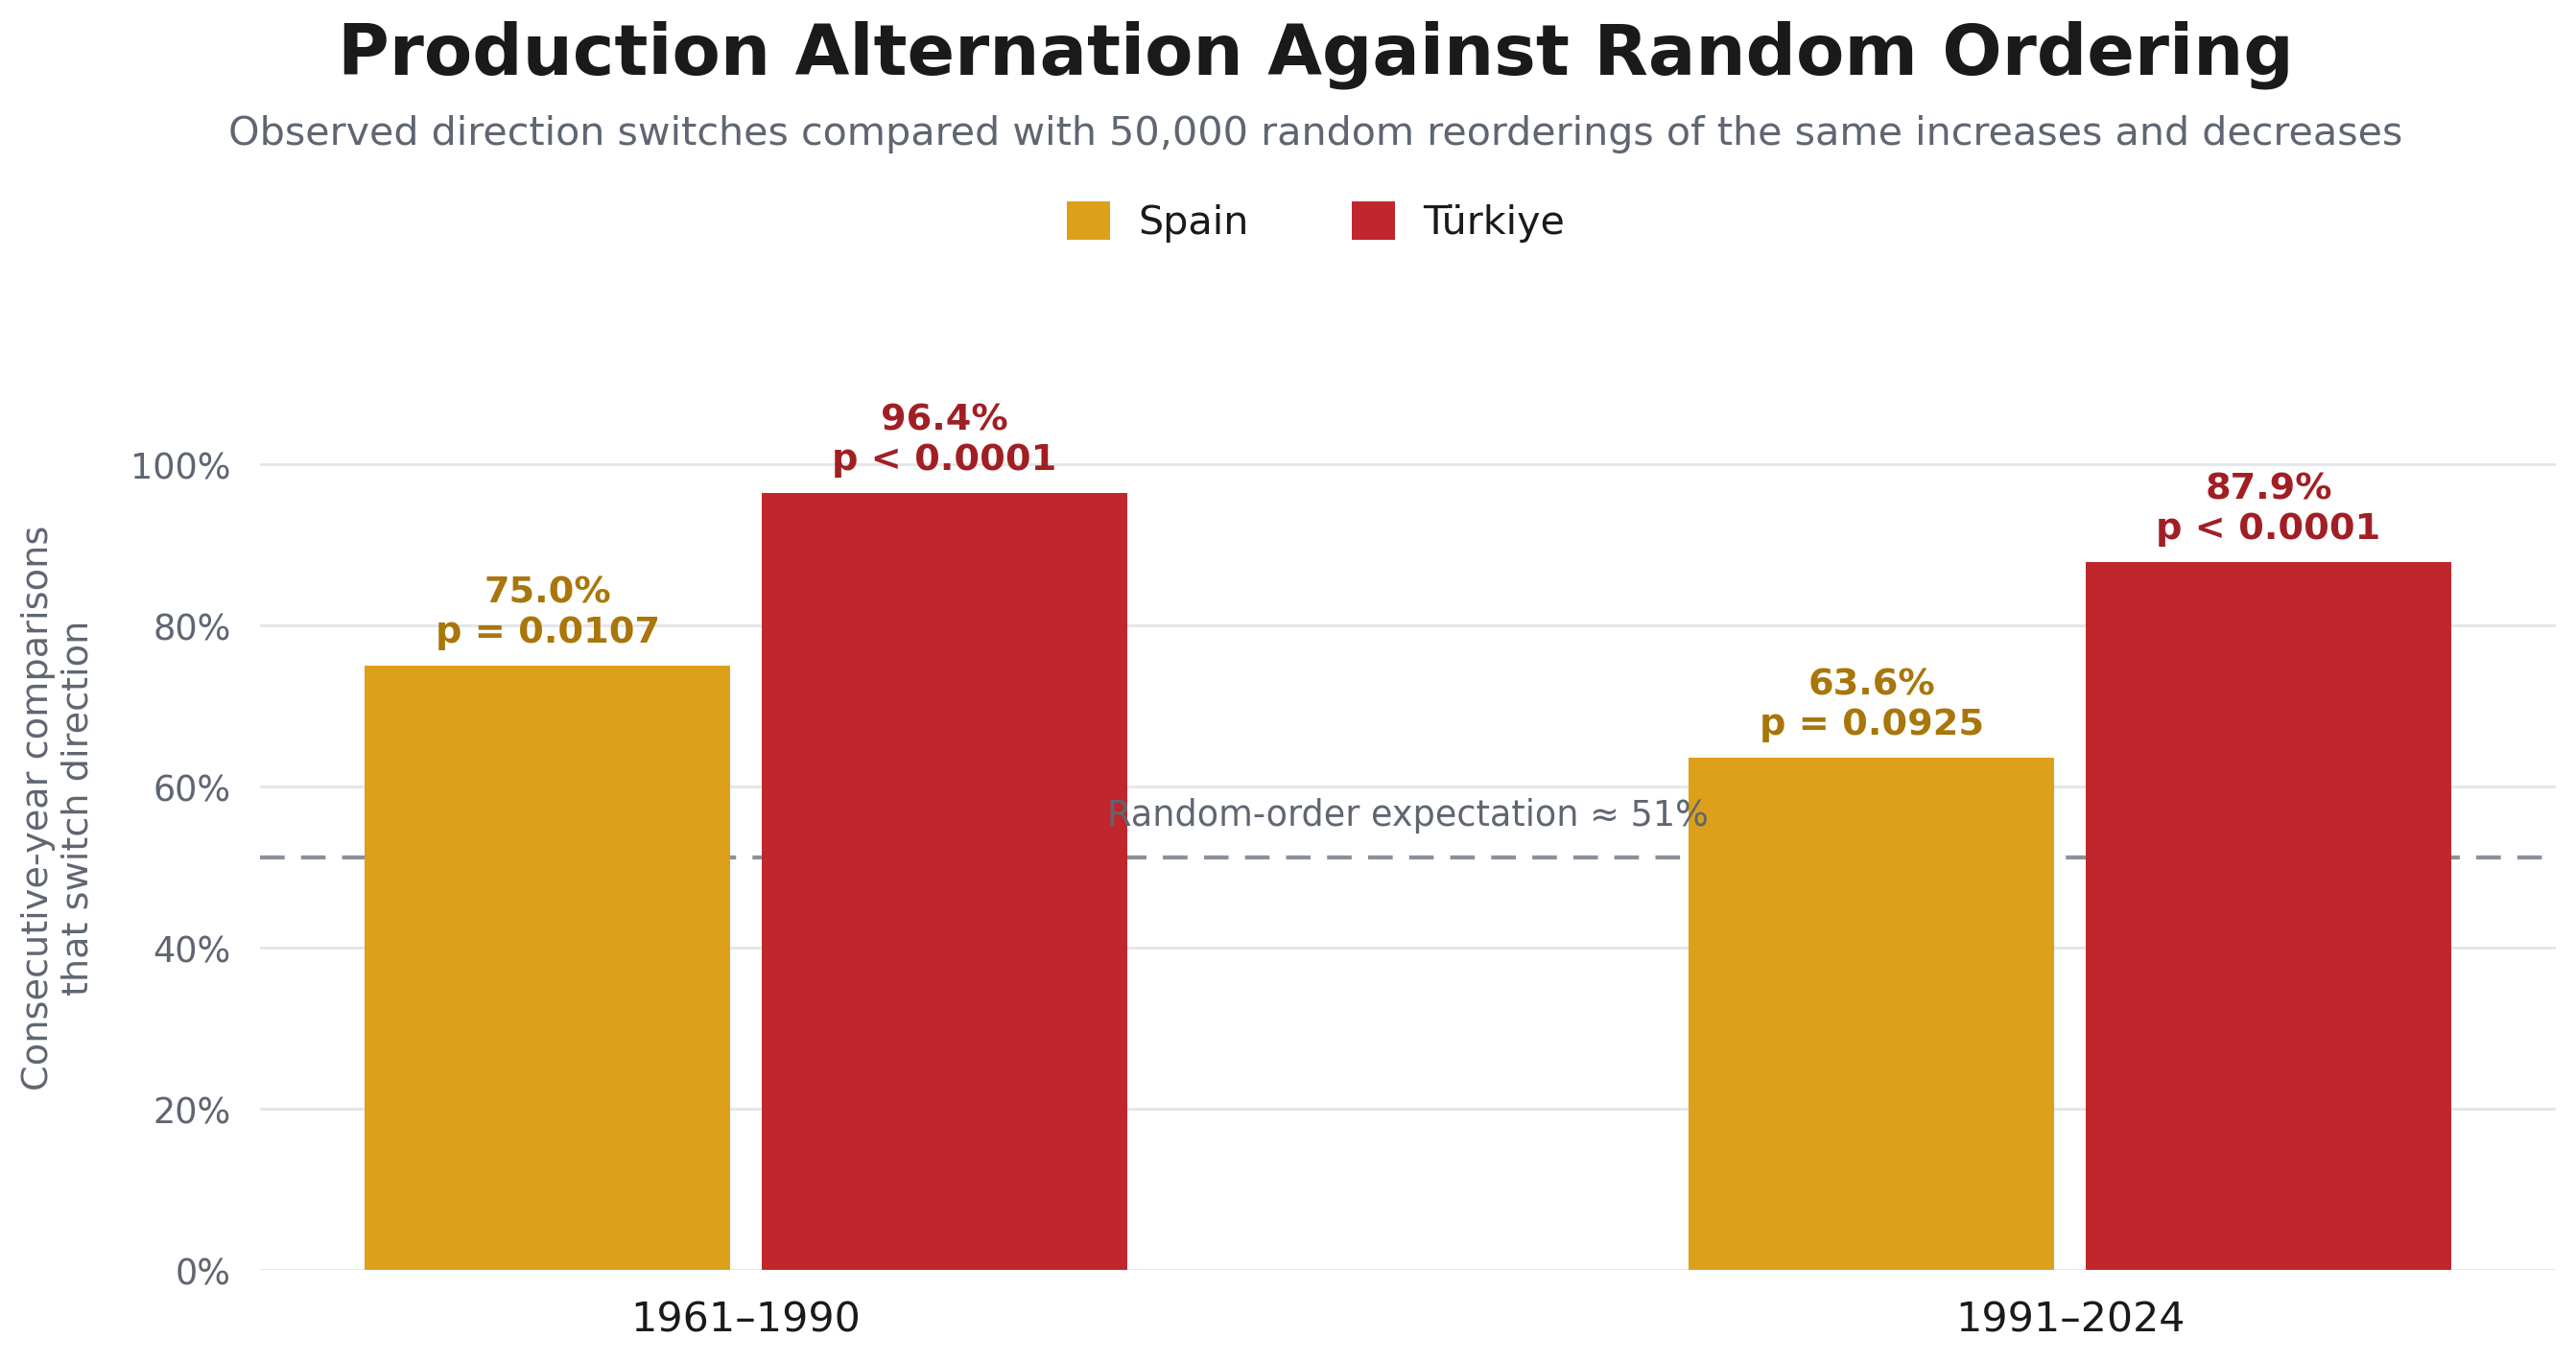

In [13]:
periods = list(ANALYSIS_PERIODS)
x = np.arange(len(periods))
width = 0.3

fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=220)
fig.subplots_adjust(left=0.10, right=0.97, top=0.755, bottom=0.145)

for country, offset in zip(RHYTHM_COUNTRIES, [-width / 2, width / 2]):
    subset = alternation_results[alternation_results["country"] == country]
    subset = subset.set_index("period").reindex(periods)

    bars = ax.bar(
        x + offset,
        subset["observed_alternation_pct"],
        width * 0.92,
        label=country,
        color=COUNTRY_COLORS[country],
        zorder=3,
    )

    for bar, (_, row) in zip(bars, subset.iterrows()):
        ax.annotate(
            f"{row['observed_alternation_pct']:.1f}%\n"
            + ("p < 0.0001" if row["p_value"] < 0.0001 else f"p = {row['p_value']:.4f}"),
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=12.5,
            fontweight="bold",
            color=LABEL_COLORS[country],
            zorder=4,
        )

# What random ordering would give, averaged across the runs
random_expectation = alternation_results["random_mean_pct"].mean()

ax.axhline(
    random_expectation,
    color="#8A919C", linewidth=1.4, linestyle=(0, (6, 4)), zorder=2,
)

# Sits in the gap between the two period groups so it never covers a bar
ax.text(
    0.5, random_expectation + 3,
    f"Random-order expectation ≈ {random_expectation:.0f}%",
    ha="center", va="bottom", fontsize=12, color=MUTED, zorder=4,
)

ax.set_ylim(0, 115)
ax.set_yticks(range(0, 101, 20))
ax.set_yticklabels([f"{t}%" for t in range(0, 101, 20)], fontsize=12, color=MUTED)
ax.set_xticks(x)
ax.set_xticklabels(periods, fontsize=14, color=INK)
ax.tick_params(axis="both", length=0, pad=10)

ax.set_ylabel(
    "Consecutive-year comparisons\nthat switch direction",
    fontsize=12.5, color=MUTED, labelpad=12,
)

ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)

for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)

fig.text(
    0.5, 0.945,
    "Production Alternation Against Random Ordering",
    ha="center", va="center", fontsize=24, fontweight="bold", color=INK,
)

fig.text(
    0.5, 0.893,
    f"Observed direction switches compared with {N_PERMUTATIONS:,} random "
    "reorderings of the same increases and decreases",
    ha="center", va="center", fontsize=13.5, color=MUTED,
)

legend = fig.legend(
    *ax.get_legend_handles_labels(),
    loc="center", bbox_to_anchor=(0.5, 0.835),
    ncol=2, frameon=False, fontsize=13.5,
    handlelength=1.1, handleheight=1.1, handletextpad=0.7, columnspacing=2.6,
)

for text in legend.get_texts():
    text.set_color(INK)

save_figure(fig, "faostat_alternation_rates.png")
plt.show()

**Interpretation:** Türkiye alternates substantially more than random ordering
would produce, in both periods. Spain shows the pattern in 1961–1990 but it is
weaker and not significant at the 5% level in 1991–2024, which is consistent
with irrigation and intensification smoothing the biennial cycle.

This is a statement about rhythm, not about totals. It does not say anything
about which country produces more.

## 10. Statistical Summary

In [14]:
summary = alternation_results.copy()

summary["observed_alternation_pct"] = summary["observed_alternation_pct"].round(1)
summary["random_mean_pct"] = summary["random_mean_pct"].round(1)
summary["p_value"] = summary["p_value"].round(4)
summary["significant_at_5pct"] = summary["p_value"] < 0.05

summary.columns = [
    "Country", "Period", "Observed alternation (%)",
    "Random-order mean (%)", "p-value", "Significant at 5%",
]

summary

,Country,Period,Observed alternation (%),Random-order mean (%),p-value,Significant at 5%
0,Spain,1961–1990,75.0,51.7,0.0107,True
1,Spain,1991–2024,63.6,50.8,0.0925,False
2,Türkiye,1961–1990,96.4,51.8,0.0000,True
3,Türkiye,1991–2024,87.9,50.8,0.0000,True


## 11. Output Files

| File | Used in |
| --- | --- |
| `olive_production_all_countries.png` | EDA, blog |
| `agricultural_change_flag_colors.png` | Presentation |
| `italy_flat_vs_world.png` | Presentation, blog |
| `faostat_direction_rhythm.png` | Appendix |
| `faostat_alternation_rates.png` | Appendix |

All figures are written to `outputs/figures/faostat/` at 220 dpi.

In [15]:
for path in sorted(FIGURE_DIR.glob("*.png")):
    print(f"{path.name:<42} {path.stat().st_size / 1024:>7.0f} KB")

agricultural_change_flag_colors.png            147 KB
bubble_snapshot_1961.png                       125 KB
bubble_snapshot_1985.png                       145 KB
bubble_snapshot_2000.png                       151 KB
bubble_snapshot_2010.png                       154 KB
bubble_snapshot_2024.png                       155 KB
faostat_alternation_rates.png                  177 KB
faostat_direction_rhythm.png                   114 KB
italy_flat_vs_world.png                        341 KB
olive_production_all_countries.png             454 KB
production_rank_slope.png                      228 KB
